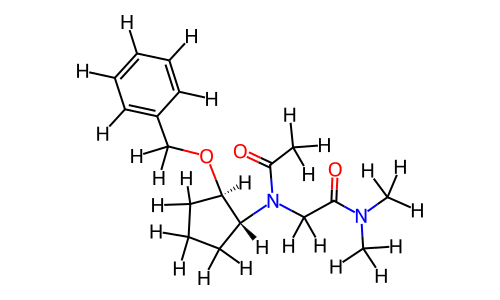

In [1]:
from openff.toolkit import Molecule

mol = Molecule.from_file("s06.sdf")

# visualize
mol.visualize()

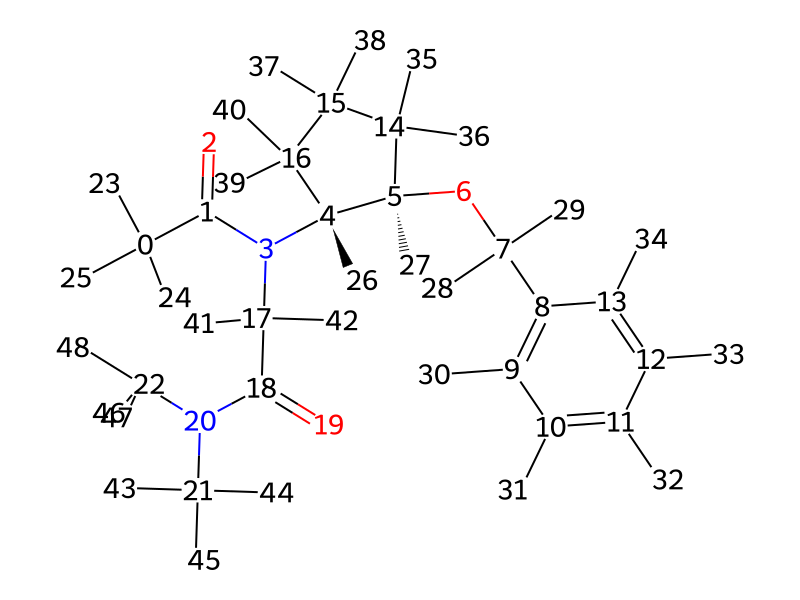

In [39]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

rdmol = Chem.MolFromMolFile("s06.sdf", removeHs=False)

for atom in rdmol.GetAtoms():
    atom.SetProp("atomLabel", str(atom.GetIdx()))

rdDepictor.Compute2DCoords(rdmol)

drawer = rdMolDraw2D.MolDraw2DCairo(800, 600)
drawer.DrawMolecule(rdmol)
drawer.FinishDrawing()

with open("s06.png", "wb") as f:
    f.write(drawer.GetDrawingText())

display(Image(filename="s06.png"))

[np.float64(-88.14988382951913), np.float64(89.0241638211181), np.float64(-89.93651717849393), np.float64(-89.73289239919102), np.float64(89.27837982712731), np.float64(-89.89278493740709), np.float64(-86.67728223584577), np.float64(89.88545134605211), np.float64(86.82727393333444), np.float64(-86.6126538757799), np.float64(-85.41678385746117), np.float64(-89.9992327529092), np.float64(-85.9996855084283), np.float64(89.27649229873184), np.float64(-84.01506438584471), np.float64(-86.73433633646343), np.float64(-89.95223414069956), np.float64(88.75035925185281), np.float64(-86.1425317382018), np.float64(-83.18971856918041), np.float64(89.42558322702794), np.float64(-89.81201929240804), np.float64(87.52207906859095), np.float64(89.46372164517928), np.float64(86.58138665293731), np.float64(86.89304992997451), np.float64(-85.26597887471623), np.float64(88.4999108670143), np.float64(-83.84458877394069), np.float64(88.12216024215213), np.float64(87.42680876543537), np.float64(-89.995736795098

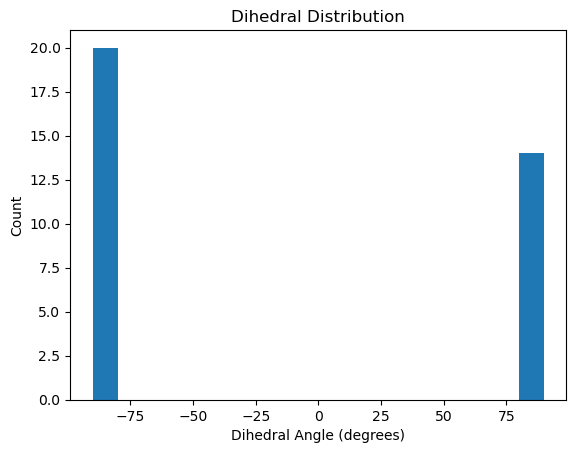

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from openff.toolkit import Molecule

def dihedral_angle(p0, p1, p2, p3):
    """Return dihedral angle in degrees."""
    b0 = -1.0 * (p1 - p0)
    b1 = p2 - p1
    b2 = p3 - p2

    # normalize b1 so projection is stable
    b1 /= np.linalg.norm(b1)

    # vectors perpendicular to b1
    v = b0 - np.dot(b0, b1) * b1
    w = b2 - np.dot(b2, b1) * b1

    x = np.dot(v, w)
    y = np.dot(np.cross(b1, v), w)

    angle = np.degrees(np.arctan2(y, x))
    return angle

mol = Molecule.from_file("s06.sdf")
mol.generate_conformers(n_conformers=200)

# phi atom index
dihedral_atoms = [1, 3, 17, 18]

angles = []

for conf in mol.conformers:
    coords = conf.m_as("angstrom")   # shape: (n_atoms, 3)
    i, j, k, l = dihedral_atoms
    angle = dihedral_angle(coords[i], coords[j], coords[k], coords[l])
    angles.append(angle)

print(angles)

plt.hist(angles, bins=18)
plt.xlabel("Dihedral Angle (degrees)")
plt.ylabel("Count")
plt.title("Dihedral Distribution")
plt.show()


In [41]:
for idx in dihedral_atoms:
    atom = mol.atoms[idx]
    print(
        f"index={idx}, element={atom.symbol}, atomic_number={atom.atomic_number}, "
        f"formal_charge={atom.formal_charge}"
    )

index=1, element=C, atomic_number=6, formal_charge=0 elementary_charge
index=3, element=N, atomic_number=7, formal_charge=0 elementary_charge
index=17, element=C, atomic_number=6, formal_charge=0 elementary_charge
index=18, element=C, atomic_number=6, formal_charge=0 elementary_charge


In [42]:
import numpy as np

angles_array = np.array(angles)

counts, bins = np.histogram(angles_array, bins=18)

# find 
top2 = np.argsort(counts)[-2:]

peak_angles = [(bins[i] + bins[i+1]) / 2 for i in top2]

print("Top dihedral angles:")
for p in peak_angles:
    print(f"≈ {p:.2f}°")

Top dihedral angles:
≈ 84.89°
≈ -85.00°


[np.float64(-179.5336753677692), np.float64(179.69625303107892), np.float64(-179.98608561676164), np.float64(-179.98493370592942), np.float64(-179.29461129866004), np.float64(-0.15944332078465462), np.float64(-178.80908881070187), np.float64(179.96586447094643), np.float64(-2.486153783454682), np.float64(-179.2492781554123), np.float64(-179.19480852979794), np.float64(-179.99976901205756), np.float64(-178.61075328539673), np.float64(179.75473976729458), np.float64(5.145601171069754), np.float64(-178.81034182286845), np.float64(-179.99943409508407), np.float64(-0.5472482382144578), np.float64(-178.69843625249362), np.float64(4.964679674060573), np.float64(-179.9984506237744), np.float64(-0.3017896915585059), np.float64(179.14971977048535), np.float64(179.83957010269907), np.float64(179.0034650085939), np.float64(-1.96025334878176), np.float64(3.0809151666218213), np.float64(179.52861195739814), np.float64(5.392304368961659), np.float64(-1.6870683302463487), np.float64(-1.782532571734924

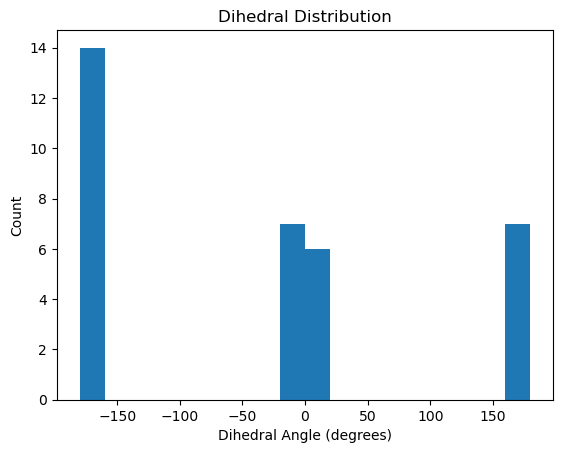

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from openff.toolkit import Molecule

def dihedral_angle(p0, p1, p2, p3):
    """Return dihedral angle in degrees."""
    b0 = -1.0 * (p1 - p0)
    b1 = p2 - p1
    b2 = p3 - p2

    # normalize b1 so projection is stable
    b1 /= np.linalg.norm(b1)

    # vectors perpendicular to b1
    v = b0 - np.dot(b0, b1) * b1
    w = b2 - np.dot(b2, b1) * b1

    x = np.dot(v, w)
    y = np.dot(np.cross(b1, v), w)

    angle = np.degrees(np.arctan2(y, x))
    return angle

mol = Molecule.from_file("s06.sdf")
mol.generate_conformers(n_conformers=200)

# psi atom index
dihedral_atoms = [3, 17, 18, 20]

angles = []

for conf in mol.conformers:
    coords = conf.m_as("angstrom")   # shape: (n_atoms, 3)
    i, j, k, l = dihedral_atoms
    angle = dihedral_angle(coords[i], coords[j], coords[k], coords[l])
    angles.append(angle)

print(angles)

plt.hist(angles, bins=18)
plt.xlabel("Dihedral Angle (degrees)")
plt.ylabel("Count")
plt.title("Dihedral Distribution")
plt.show()


In [45]:
for idx in dihedral_atoms:
    atom = mol.atoms[idx]
    print(
        f"index={idx}, element={atom.symbol}, atomic_number={atom.atomic_number}, "
        f"formal_charge={atom.formal_charge}"
    )

index=3, element=N, atomic_number=7, formal_charge=0 elementary_charge
index=17, element=C, atomic_number=6, formal_charge=0 elementary_charge
index=18, element=C, atomic_number=6, formal_charge=0 elementary_charge
index=20, element=N, atomic_number=7, formal_charge=0 elementary_charge


In [46]:
import numpy as np

angles_array = np.array(angles)

counts, bins = np.histogram(angles_array, bins=18)

# find 
top2 = np.argsort(counts)[-2:]

peak_angles = [(bins[i] + bins[i+1]) / 2 for i in top2]

print("Top dihedral angles:")
for p in peak_angles:
    print(f"≈ {p:.2f}°")

Top dihedral angles:
≈ 169.97°
≈ -170.00°
